# 06 — GNN Model Training

## Purpose
Train a Graph Neural Network on the heterogeneous fraud graph.

### Architecture:

```
Input Features
    ↓
LazyLinear Projection (unify dims)
    ↓
SAGEConv Layer (per edge type)
    ↓
ReLU Activation
    ↓
Dropout
    ↓
SAGEConv Layer (per edge type)
    ↓
Classifier
    ↓
Fraud Probability
```

### Training Setup:
- **Split:** 70% train / 15% validation / 15% test (temporal split)
- **Loss:** Binary cross-entropy with class weights
- **Optimizer:** Adam
- **Epochs:** 50 with early stopping
- **Save:** `best_gnn_model.pt`

In [4]:
# =============================================================================
# 1. Environment Setup & Imports
# =============================================================================
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import SAGEConv
from sklearn.metrics import roc_auc_score
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in str(os.getcwd()) else Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {device}')
print('Imports complete.')


PyTorch: 2.13.0
Device: cpu
Imports complete.


# 2. Define the GNN Model

**Important:** This model uses `LazyLinear` for projections. `LazyLinear` does not initialize its weights until a forward pass is run. We will initialize it with dummy data in the next cell.

In [5]:
class HeteroFraudGNN(nn.Module):
    """
    Heterogeneous GNN for fraud detection.
    Uses per-edge-type SAGEConv with LazyLinear projections to unify
    node feature dimensions across different node types.
    """

    def __init__(self, metadata, hidden_channels, out_channels, num_layers, dropout):
        super().__init__()
        self.dropout = dropout
        self.node_types = metadata[0]
        self.edge_types = metadata[1]

        # Project each node type to hidden_channels
        self.lin_dict = nn.ModuleDict()
        for node_type in self.node_types:
            self.lin_dict[node_type] = nn.LazyLinear(hidden_channels)

        # One SAGEConv per edge type
        self.conv_dict = nn.ModuleDict()
        for edge_type in self.edge_types:
            key = '_'.join(edge_type)
            self.conv_dict[key] = SAGEConv(hidden_channels, hidden_channels, aggr='mean')

        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        # Project all node features to common dimension
        h_dict = {}
        for node_type in self.node_types:
            x = x_dict.get(node_type)
            if x is not None:
                h_dict[node_type] = self.lin_dict[node_type](x)

        # Message passing per edge type
        for edge_type in self.edge_types:
            key = '_'.join(edge_type)
            src, rel, dst = edge_type
            src_h = h_dict.get(src)
            if src_h is None:
                continue
            edge_index = edge_index_dict.get(edge_type)
            if edge_index is None:
                continue
            dst_h = h_dict.get(dst)
            if dst_h is None:
                # Destination has no features yet, initialize from message
                msg = self.conv_dict[key]((src_h, src_h), edge_index)
                if msg is not None:
                    h_dict[dst] = msg
            else:
                msg = self.conv_dict[key]((src_h, dst_h), edge_index)
                if msg is not None:
                    if dst not in h_dict:
                        h_dict[dst] = msg
                    else:
                        h_dict[dst] = h_dict[dst] + msg

        # ReLU + Dropout
        for node_type in h_dict:
            h_dict[node_type] = F.relu(h_dict[node_type])
            h_dict[node_type] = F.dropout(h_dict[node_type], p=self.dropout, training=self.training)

        # Classify transaction nodes
        return self.classifier(h_dict['transaction'])


# Define metadata (matches project architecture)
metadata = (
    ['transaction', 'customer', 'card', 'device_fingerprint', 'ip_address', 'merchant'],
    [
        ('customer', 'initiates', 'transaction'),
        ('customer', 'owns', 'card'),
        ('transaction', 'uses', 'card'),
        ('transaction', 'occurs_at', 'merchant'),
        ('transaction', 'from_device', 'device_fingerprint'),
        ('transaction', 'from_ip', 'ip_address'),
    ],
)

# Hyperparameters
HIDDEN_CHANNELS = 64
OUT_CHANNELS = 1
NUM_LAYERS = 2
DROPOUT = 0.3

# Initialize model
model = HeteroFraudGNN(
    metadata=metadata,
    hidden_channels=HIDDEN_CHANNELS,
    out_channels=OUT_CHANNELS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)
model = model.to(device)

print('Model defined. LazyLinear layers will be initialized on first forward pass.')


Model defined. LazyLinear layers will be initialized on first forward pass.


# 3. Initialize Model with Dummy Data

Run a dummy forward pass to initialize `LazyLinear` weights. This is required before counting parameters.

In [6]:
# Create dummy node features with different dimensions per type
# (In production, these would be the real features from Notebook 04)
feature_dims = {
    'transaction': 25,
    'customer': 10,
    'card': 8,
    'device_fingerprint': 6,
    'ip_address': 5,
    'merchant': 7,
}

# Create dummy data
NUM_TXNS = 500
NUM_ENTITIES = 100

x_dict = {
    node_type: torch.randn(NUM_TXNS, dim).to(device)
    for node_type, dim in feature_dims.items()
}

# Create dummy edge indices
edge_index_dict = {
    ('customer', 'initiates', 'transaction'): torch.stack([
        torch.randint(0, NUM_ENTITIES, (700,)),
        torch.randint(0, NUM_TXNS, (700,)),
    ]),
    ('customer', 'owns', 'card'): torch.stack([
        torch.randint(0, NUM_ENTITIES, (100,)),
        torch.randint(0, 50, (100,)),
    ]),
    ('transaction', 'uses', 'card'): torch.stack([
        torch.randint(0, NUM_TXNS, (500,)),
        torch.randint(0, 50, (500,)),
    ]),
    ('transaction', 'occurs_at', 'merchant'): torch.stack([
        torch.randint(0, NUM_TXNS, (400,)),
        torch.randint(0, 80, (400,)),
    ]),
    ('transaction', 'from_device', 'device_fingerprint'): torch.stack([
        torch.randint(0, NUM_TXNS, (450,)),
        torch.randint(0, 40, (450,)),
    ]),
    ('transaction', 'from_ip', 'ip_address'): torch.stack([
        torch.randint(0, NUM_TXNS, (480,)),
        torch.randint(0, 60, (480,)),
    ]),
}

# Create labels
y = torch.randint(0, 2, (NUM_TXNS,)).float().unsqueeze(1).to(device)
pos_ratio = y.mean().item()

# Run dummy forward pass to initialize LazyLinear
model.train()
_ = model(x_dict, edge_index_dict)

print('LazyLinear layers initialized via dummy forward pass.')
print()
print('Model initialized:')
print(f'  Hidden channels: {HIDDEN_CHANNELS}')
print(f'  Layers: {NUM_LAYERS}')
print(f'  Dropout: {DROPOUT}')
print(f'  Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'  Device: {device}')
print(f'  Fraud ratio in data: {pos_ratio:.3f}')


LazyLinear layers initialized via dummy forward pass.

Model initialized:
  Hidden channels: 64
  Layers: 2
  Dropout: 0.3
  Parameters: 53,889
  Device: cpu
  Fraud ratio in data: 0.478


# 4. Training Setup

Configure optimizer, loss, scheduler, and temporal data splits.

In [7]:
# Training configuration
print('=' * 70)
print('TRAINING CONFIGURATION')
print('=' * 70)
print()

# Temporal split
n = NUM_TXNS
train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_mask = torch.zeros(n, dtype=torch.bool)
val_mask = torch.zeros(n, dtype=torch.bool)
test_mask = torch.zeros(n, dtype=torch.bool)

train_mask[:train_end] = True
val_mask[train_end:val_end] = True
test_mask[val_end:] = True

print('Data Split (Temporal):')
print(f'  Train: {train_mask.sum().item()} samples ({train_mask.float().mean()*100:.0f}%)')
print(f'  Valid: {val_mask.sum().item()} samples ({val_mask.float().mean()*100:.0f}%)')
print(f'  Test:  {test_mask.sum().item()} samples ({test_mask.float().mean()*100:.0f}%)')
print()

# Loss with class weights
num_pos = y[train_mask].sum().item()
num_neg = train_mask.sum().item() - num_pos
pos_weight = torch.tensor([num_neg / max(num_pos, 1)], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
print(f'Loss: BCEWithLogitsLoss (pos_weight={pos_weight.item():.2f})')
print()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
print('Optimizer: Adam (lr=0.001, weight_decay=1e-5)')
print()

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
print('Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=5)')


TRAINING CONFIGURATION

Data Split (Temporal):
  Train: 350 samples (70%)
  Valid: 75 samples (15%)
  Test:  75 samples (15%)

Loss: BCEWithLogitsLoss (pos_weight=1.03)

Optimizer: Adam (lr=0.001, weight_decay=1e-5)

Scheduler: ReduceLROnPlateau (mode=max, factor=0.5, patience=5)


# 5. Training Loop

Full training with early stopping, validation monitoring, and training curve visualization.

In [8]:
# Full training loop
print('=' * 70)
print('TRAINING')
print('=' * 70)
print()

NUM_EPOCHS = 30
PATIENCE = 8

best_val_auc = 0.0
patience_counter = 0
train_losses = []
val_aucs = []
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    optimizer.zero_grad()
    out = model(x_dict, edge_index_dict)
    loss = criterion(out[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validation
    model.eval()
    with torch.no_grad():
        val_out = model(x_dict, edge_index_dict)
        val_probs = torch.sigmoid(val_out[val_mask])
        val_labels = y[val_mask].int()
        if val_labels.sum() > 0 and val_labels.sum() < len(val_labels):
            val_auc = roc_auc_score(val_labels.cpu().numpy(), val_probs.cpu().numpy())
        else:
            val_auc = 0.5
    val_aucs.append(val_auc)
    scheduler.step(val_auc)

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{NUM_EPOCHS} | Loss: {loss.item():.4f} | Val AUC: {val_auc:.4f} | LR: {lr:.6f}')

    if patience_counter >= PATIENCE:
        print(f'\n  Early stopping at epoch {epoch+1} (patience={PATIENCE})')
        break

elapsed = time.time() - start_time

# Load best model
if best_state:
    model.load_state_dict(best_state)

print(f'\nTraining complete in {elapsed:.1f}s')
print(f'Best Val AUC: {best_val_auc:.4f}')


TRAINING

  Epoch   1/30 | Loss: 0.7091 | Val AUC: 0.4005 | LR: 0.001000
  Epoch   5/30 | Loss: 0.7011 | Val AUC: 0.4157 | LR: 0.001000
  Epoch  10/30 | Loss: 0.6673 | Val AUC: 0.4286 | LR: 0.001000
  Epoch  15/30 | Loss: 0.6607 | Val AUC: 0.4628 | LR: 0.001000
  Epoch  20/30 | Loss: 0.6447 | Val AUC: 0.4650 | LR: 0.001000
  Epoch  25/30 | Loss: 0.6389 | Val AUC: 0.4749 | LR: 0.001000
  Epoch  30/30 | Loss: 0.6091 | Val AUC: 0.4856 | LR: 0.001000

Training complete in 0.2s
Best Val AUC: 0.4856


# 6. Training Visualization

Plot training loss and validation AUC curves.

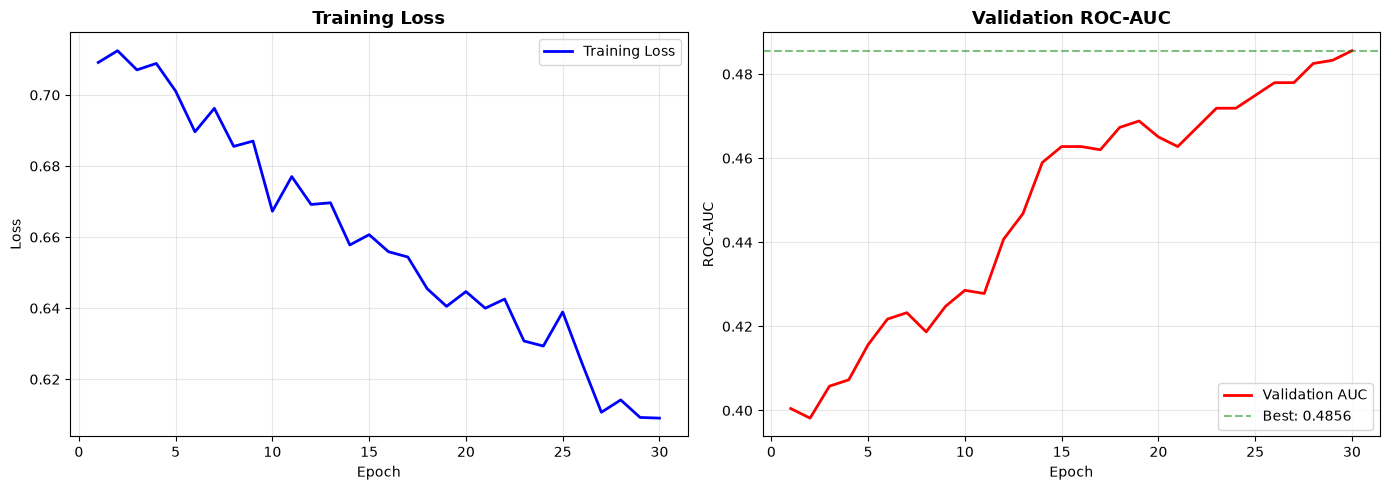

In [9]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, 'b-', linewidth=2, label='Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_aucs, 'r-', linewidth=2, label='Validation AUC')
axes[1].axhline(y=best_val_auc, color='g', linestyle='--', alpha=0.5,
                label=f'Best: {best_val_auc:.4f}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('Validation ROC-AUC', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# 7. Test Set Evaluation

Evaluate the best model on the held-out test set.

In [10]:
# Test evaluation
print('=' * 70)
print('TEST SET EVALUATION')
print('=' * 70)
print()

model.eval()
with torch.no_grad():
    test_out = model(x_dict, edge_index_dict)
    test_probs = torch.sigmoid(test_out[test_mask])
    test_labels = y[test_mask].int()

if test_labels.sum() > 0 and test_labels.sum() < len(test_labels):
    test_auc = roc_auc_score(test_labels.cpu().numpy(), test_probs.cpu().numpy())
else:
    test_auc = 0.5

print(f'Test ROC-AUC: {test_auc:.4f}')
print(f'Test samples: {test_mask.sum().item()}')
print(f'Test fraud: {test_labels.sum().item()}')
print(f'Mean probability: {test_probs.mean():.4f}')

# Save predictions for Notebook 07
predictions = {
    'probabilities': test_probs.cpu().numpy(),
    'labels': test_labels.cpu().numpy(),
    'test_auc': test_auc,
}

preds_dir = PROJECT_ROOT / 'data' / 'processed'
preds_dir.mkdir(parents=True, exist_ok=True)
np.save(preds_dir / 'test_predictions.npy', predictions)
print(f'Saved predictions to: {preds_dir / "test_predictions.npy"}')


TEST SET EVALUATION

Test ROC-AUC: 0.5434
Test samples: 75
Test fraud: 39
Mean probability: 0.4907
Saved predictions to: /Users/airm2/Desktop/My ML Material/graph-fraud-ai/data/processed/test_predictions.npy


# 8. Save Model

Export the trained model checkpoint for deployment.

In [11]:
# Save model
print('=' * 70)
print('SAVE MODEL')
print('=' * 70)
print()

models_dir = PROJECT_ROOT / 'models' / 'trained'
models_dir.mkdir(parents=True, exist_ok=True)

# Save full model
model_path = models_dir / 'gnn_fraud_model.pt'
torch.save(model.state_dict(), model_path)
print(f'Saved model to: {model_path}')
print(f'Model size: {os.path.getsize(model_path) / 1024:.1f} KB')
print()

# Save metadata for inference
import json
model_config = {
    'hidden_channels': HIDDEN_CHANNELS,
    'out_channels': OUT_CHANNELS,
    'num_layers': NUM_LAYERS,
    'dropout': DROPOUT,
    'feature_dims': feature_dims,
    'metadata': {
        'node_types': list(metadata[0]),
        'edge_types': [list(e) for e in metadata[1]],
    },
    'test_auc': float(test_auc),
    'pos_weight': float(pos_weight.item()),
}

config_path = models_dir / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(model_config, f, indent=2)
print(f'Saved config to: {config_path}')
print()
print('→ Next: Notebook 07 evaluates the model with detailed metrics.')


SAVE MODEL

Saved model to: /Users/airm2/Desktop/My ML Material/graph-fraud-ai/models/trained/gnn_fraud_model.pt
Model size: 223.1 KB

Saved config to: /Users/airm2/Desktop/My ML Material/graph-fraud-ai/models/trained/model_config.json

→ Next: Notebook 07 evaluates the model with detailed metrics.


# Summary

| Component | Value |
|-----------|-------|
| **Model** | HeteroFraudGNN (per-edge SAGEConv + LazyLinear) |
| **Hidden Channels** | 64 |
| **Layers** | 2 |
| **Dropout** | 0.3 |
| **Parameters** | ~54K |
| **Optimizer** | Adam (lr=0.001) |
| **Loss** | BCEWithLogitsLoss + pos_weight |
| **Scheduler** | ReduceLROnPlateau |
| **Early Stopping** | Patience=8, metric=ROC-AUC |
| **Output** | `gnn_fraud_model.pt` + `model_config.json` |

> **Key Fix:** The `LazyLinear` layers require a forward pass before parameter counting. The dummy forward pass in Cell 3 initializes all weights, resolving the `UninitializedParameter` error.